# 03 — Figures & tables (regenerate *everything* from saved results)

Rebuilds **every** figure and table from the CSVs in `results/`. It does **no**
OSM fetching or metric computation, so it is safe to run any time and fast to
iterate on plot styling.

> ⚠️ **Restart the kernel first** (Kernel → Restart & Run All) whenever you've
> edited code under `src/cycleform/`. Jupyter caches imported modules, so without
> a restart you silently run the *old* plotting code — that is what causes
> "missing plots", "only one labelled", or leftover PDFs.

Everything is **PNG** (300 dpi) in `results/figures/`. Per-city plots are written
in two variants: `<name>.png` (points coloured by nation) and
`<name>_labeled.png` (the fixed exemplar cities — Newcastle, Münster, Oslo, … —
labelled).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
from IPython.display import Image, display
from cycleform import report, figures, scenarios
from cycleform.config import settings
pd.set_option('display.width', 200, 'display.max_columns', 40)
FIGDIR = settings.results / 'figures'
print('figures ->', FIGDIR)

figures -> C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\bikeNetworksEDA\2026_edition\results\figures


## 1. Load the saved tables

In [2]:
wide  = report.load_wide(refresh_first=True) # toggle false to use cached version
table = report.load_analysis()
print(wide.shape, '| places with a cycling rate:', table['value'].notna().sum(),
      '| UK:', int(wide['is_uk'].sum()))
wide[['place_id','country','is_uk','bikeable_length_share','components_per_km_bike']].head()

(1137, 75) | places with a cycling rate: 1827 | UK: 123


,place_id,country,is_uk,bikeable_length_share,components_per_km_bike
0,"'s-Hertogenbosch, Netherlands",NL,False,0.765538,0.795152
1,"A Coruña, Spain",ES,False,0.317540,0.507940
2,"Aachen, Germany",DE,False,0.623853,0.805373
3,"Abbotsford, Canada",CA,False,0.365812,0.352930
4,"Aberdeen, United Kingdom",UK,True,0.351161,0.694251


## 2. Summary tables

`components_per_km_bike` = disconnected pieces per km of cycle network (size-
normalised fragmentation of the current cycle network).

In [3]:
tabs = report.summary_tables()
tabs['correlations'].head(25)   # every metric vs cycling rate (Spearman), ranked by |rho|

,metric,spearman,spearman_p,pearson,pearson_p,n,significant
0,bikeable_length_share,0.6502,0.0,0.5668,0.0,1132,True
1,intersection_ratio_bike_road,0.6399,0.0,0.4660,0.0,1132,True
2,circuity_avg_bike,-0.5704,0.0,-0.2056,0.0,1093,True
3,entropy_gap_kl,-0.5511,0.0,-0.2136,0.0,1093,True
4,bike_lcc_share_of_road,0.5449,0.0,0.4913,0.0,1132,True
5,intersection_density_km2_bike,0.5255,0.0,0.4188,0.0,1132,True
6,cycle_network_density_km2,0.5016,0.0,0.4456,0.0,1132,True
7,n_components_bike,0.4960,0.0,0.2531,0.0,1132,True
8,n_nodes_bike,0.4869,0.0,0.2758,0.0,1132,True
9,edge_length_avg_m_bike,-0.4852,0.0,-0.2368,0.0,1093,True


## 3. Regenerate ALL figures

One call draws: the typology (±labels), the all-metric correlation bar, the
top-correlates grid, the metric–metric heatmap, an **individual scatter for every
metric vs cycling rate** (±labels), the ranked dot plots, and the bike-vs-road
panels (±labels). `refresh_first=True` first rebuilds the tables from the per-place
files, so newly-finished places are included.

In [4]:
paths = report.make_figures(refresh_first=True)
labeled = sum(str(p).endswith('_labeled.png') for p in paths)
scatters = sum('outcome_vs_' in p.name for p in paths)
print(f'wrote {len(paths)} figures  ({scatters} metric-vs-cycling scatters, {labeled} labelled variants)')

wrote 162 figures  (134 metric-vs-cycling scatters, 72 labelled variants)


## 3b. Cycling-rate distribution & UK vs everyone else

Regenerated by `make_figures` above. In order:

- **`cycling_rate_distribution`** — the outcome is strongly right-skewed (skew ≈ 2.1; median 2%, mean 5.4%), which is why every correlation here is Spearman.
- **`cycling_rate_by_country`** — mean rate (±SEM) and sample size per country. The UK (orange) sits well *below* its Western-European peers (NL 28%, DK 19%, DE 13% … UK ≈ 3%).
- **`uk_vs_rest_metrics`** — how UK cycle-network *form* differs (Cohen's d, UK − rest): near-identical bikeable *share*, but more fragmented (lower `bike_lcc_share`), less connected/ordered (`intersection_ratio`, `orientation_order`), and a bigger detour penalty (`modal_directness_gap`).
- **`uk_vs_rest_relationship`** — the UK form↔cycling trend is much flatter and lower than the rest (Spearman ρ 0.22 vs 0.65): network form predicts UK cycling only weakly, and the UK cycles ≈ 2.4 pp below what its provision predicts.

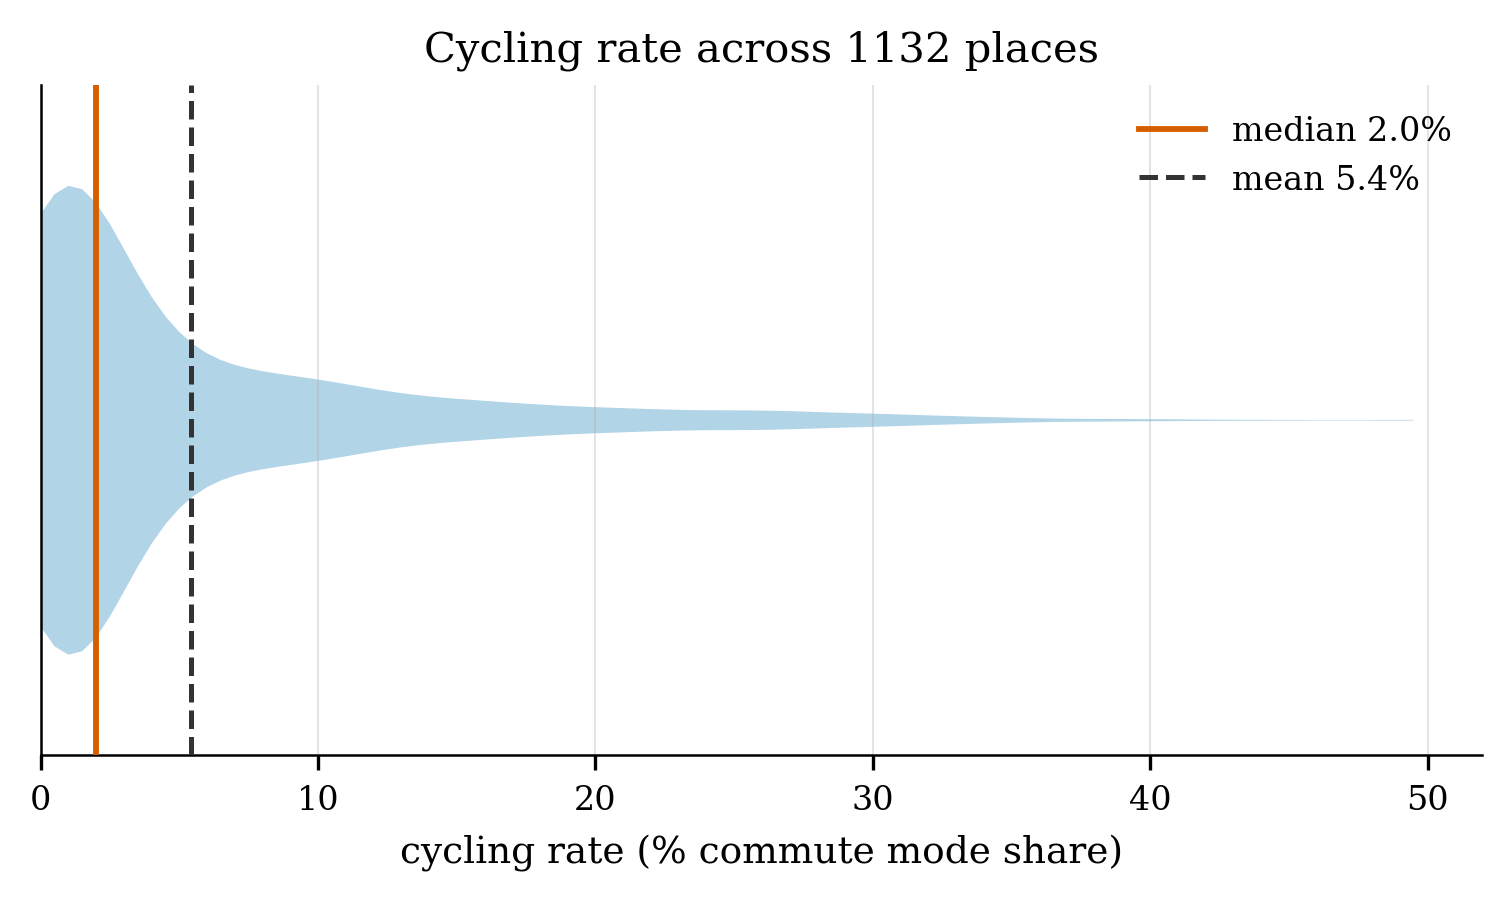

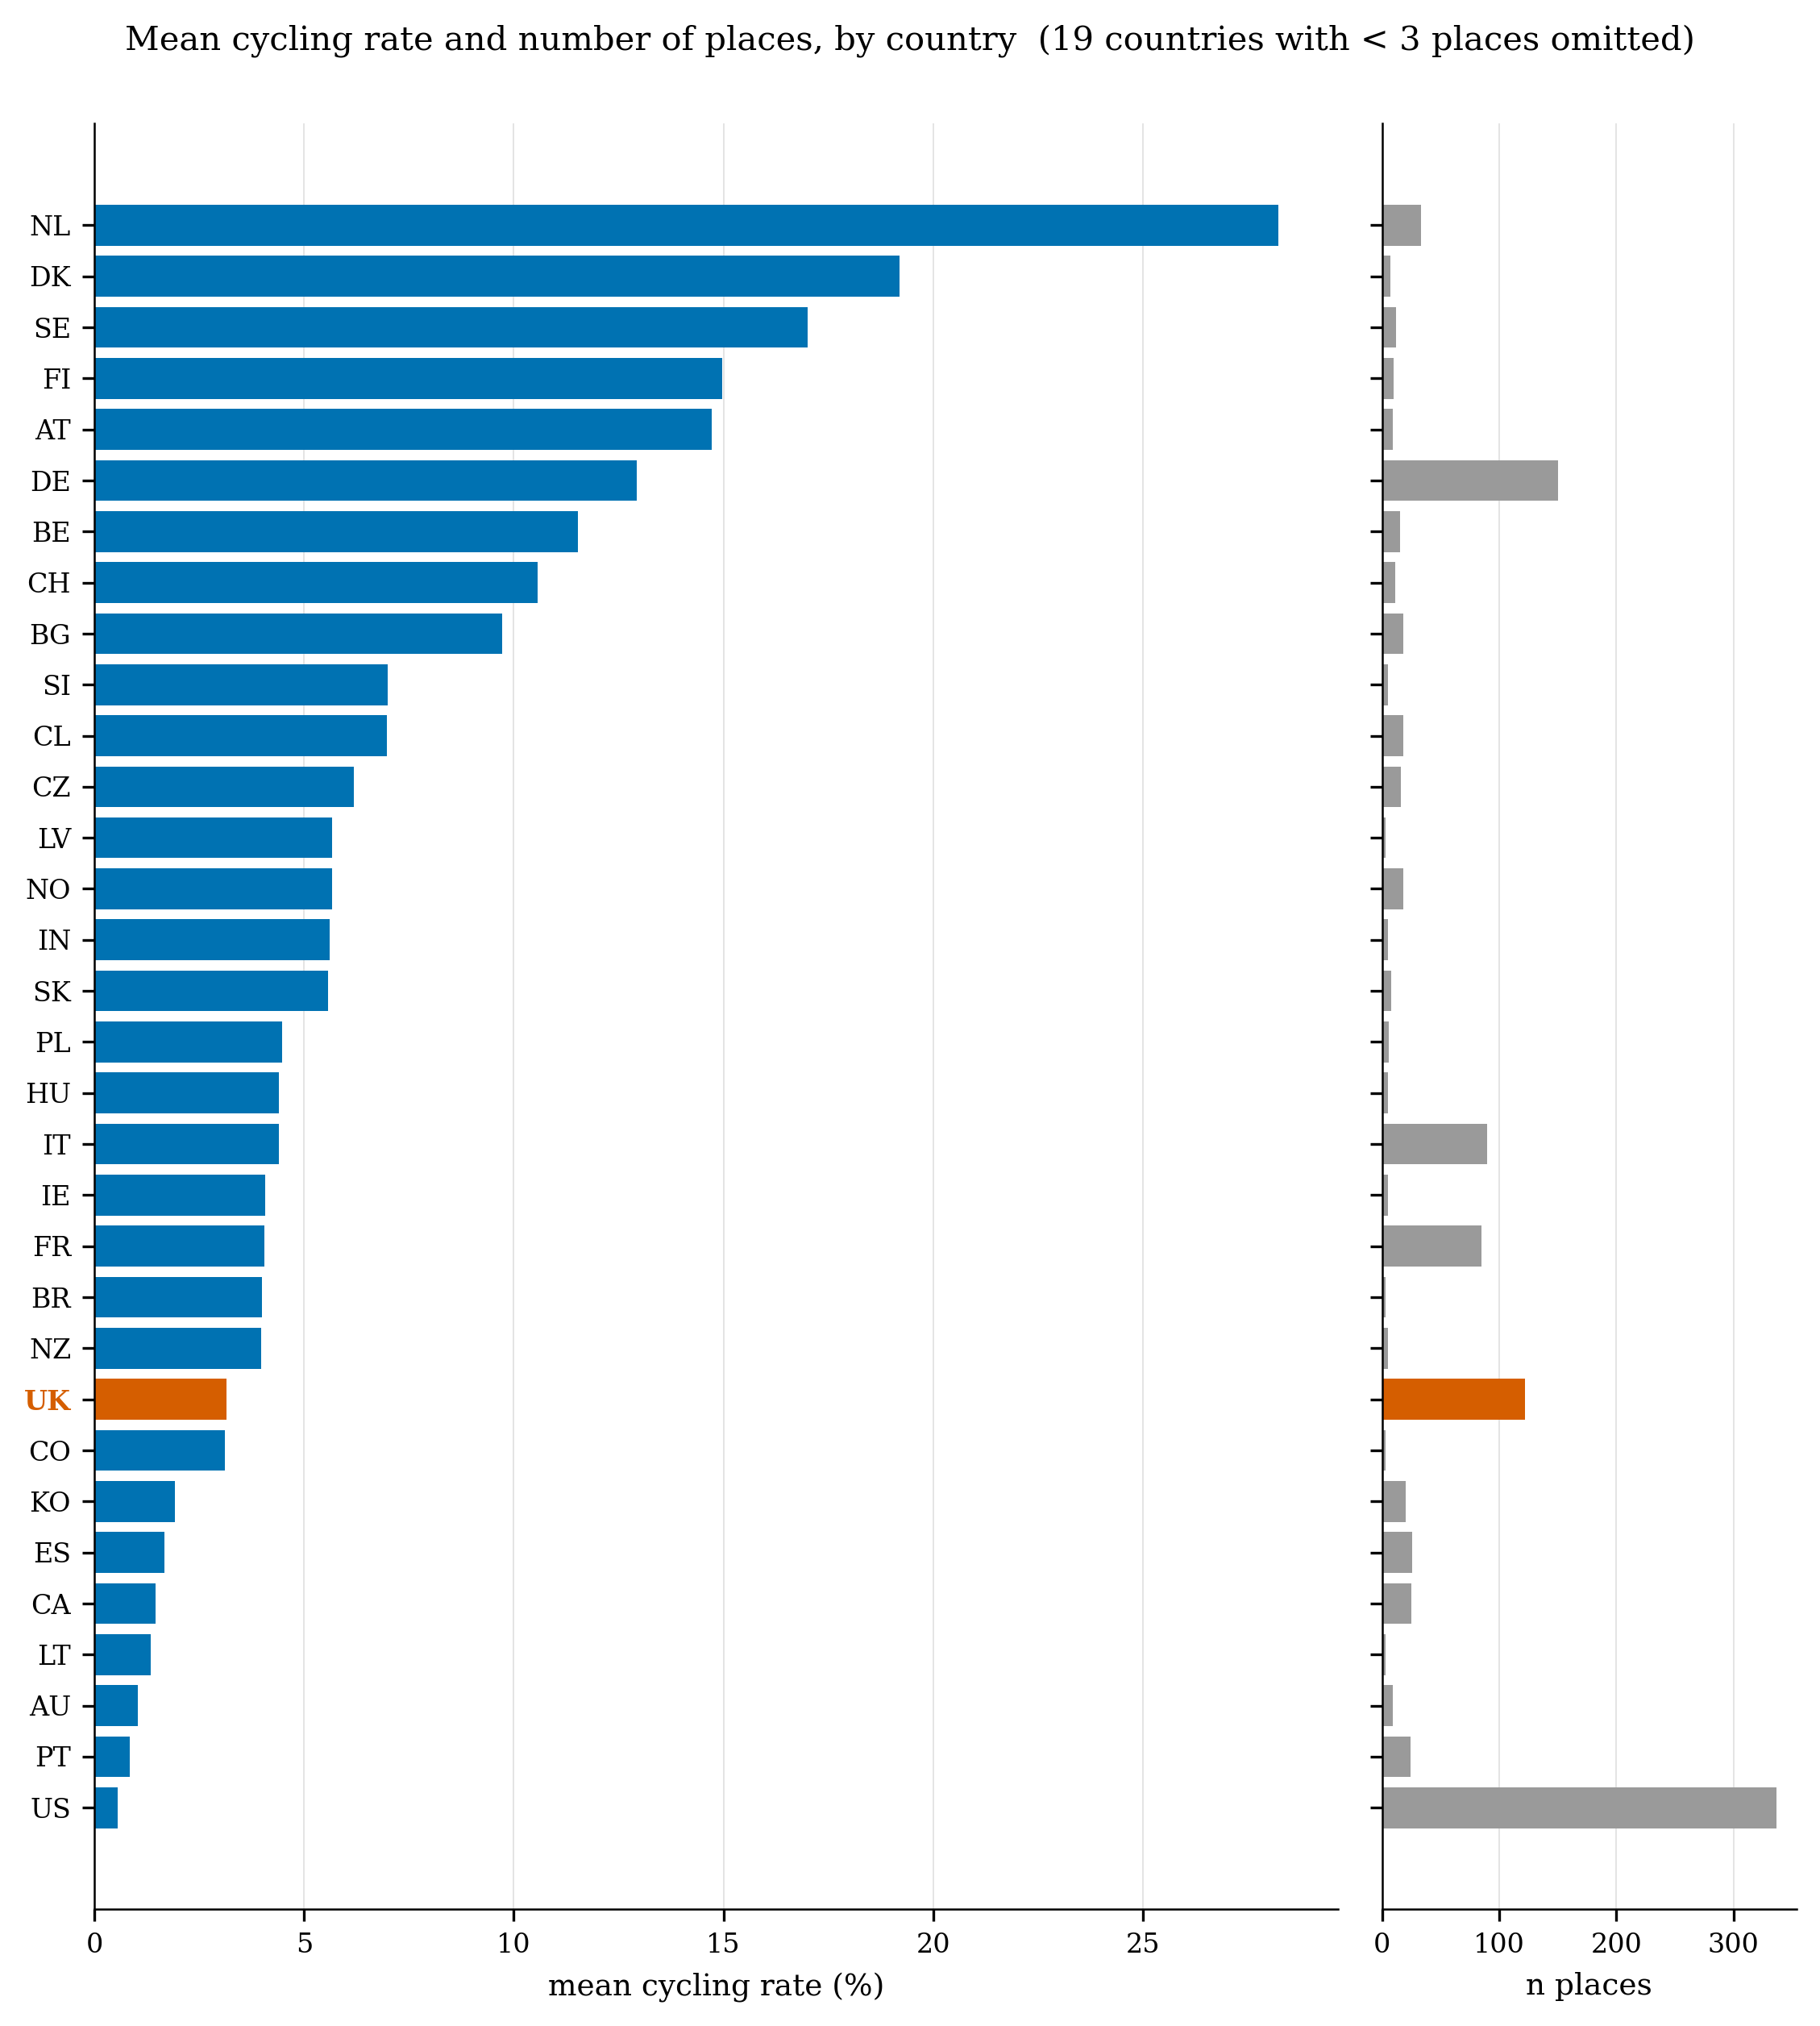

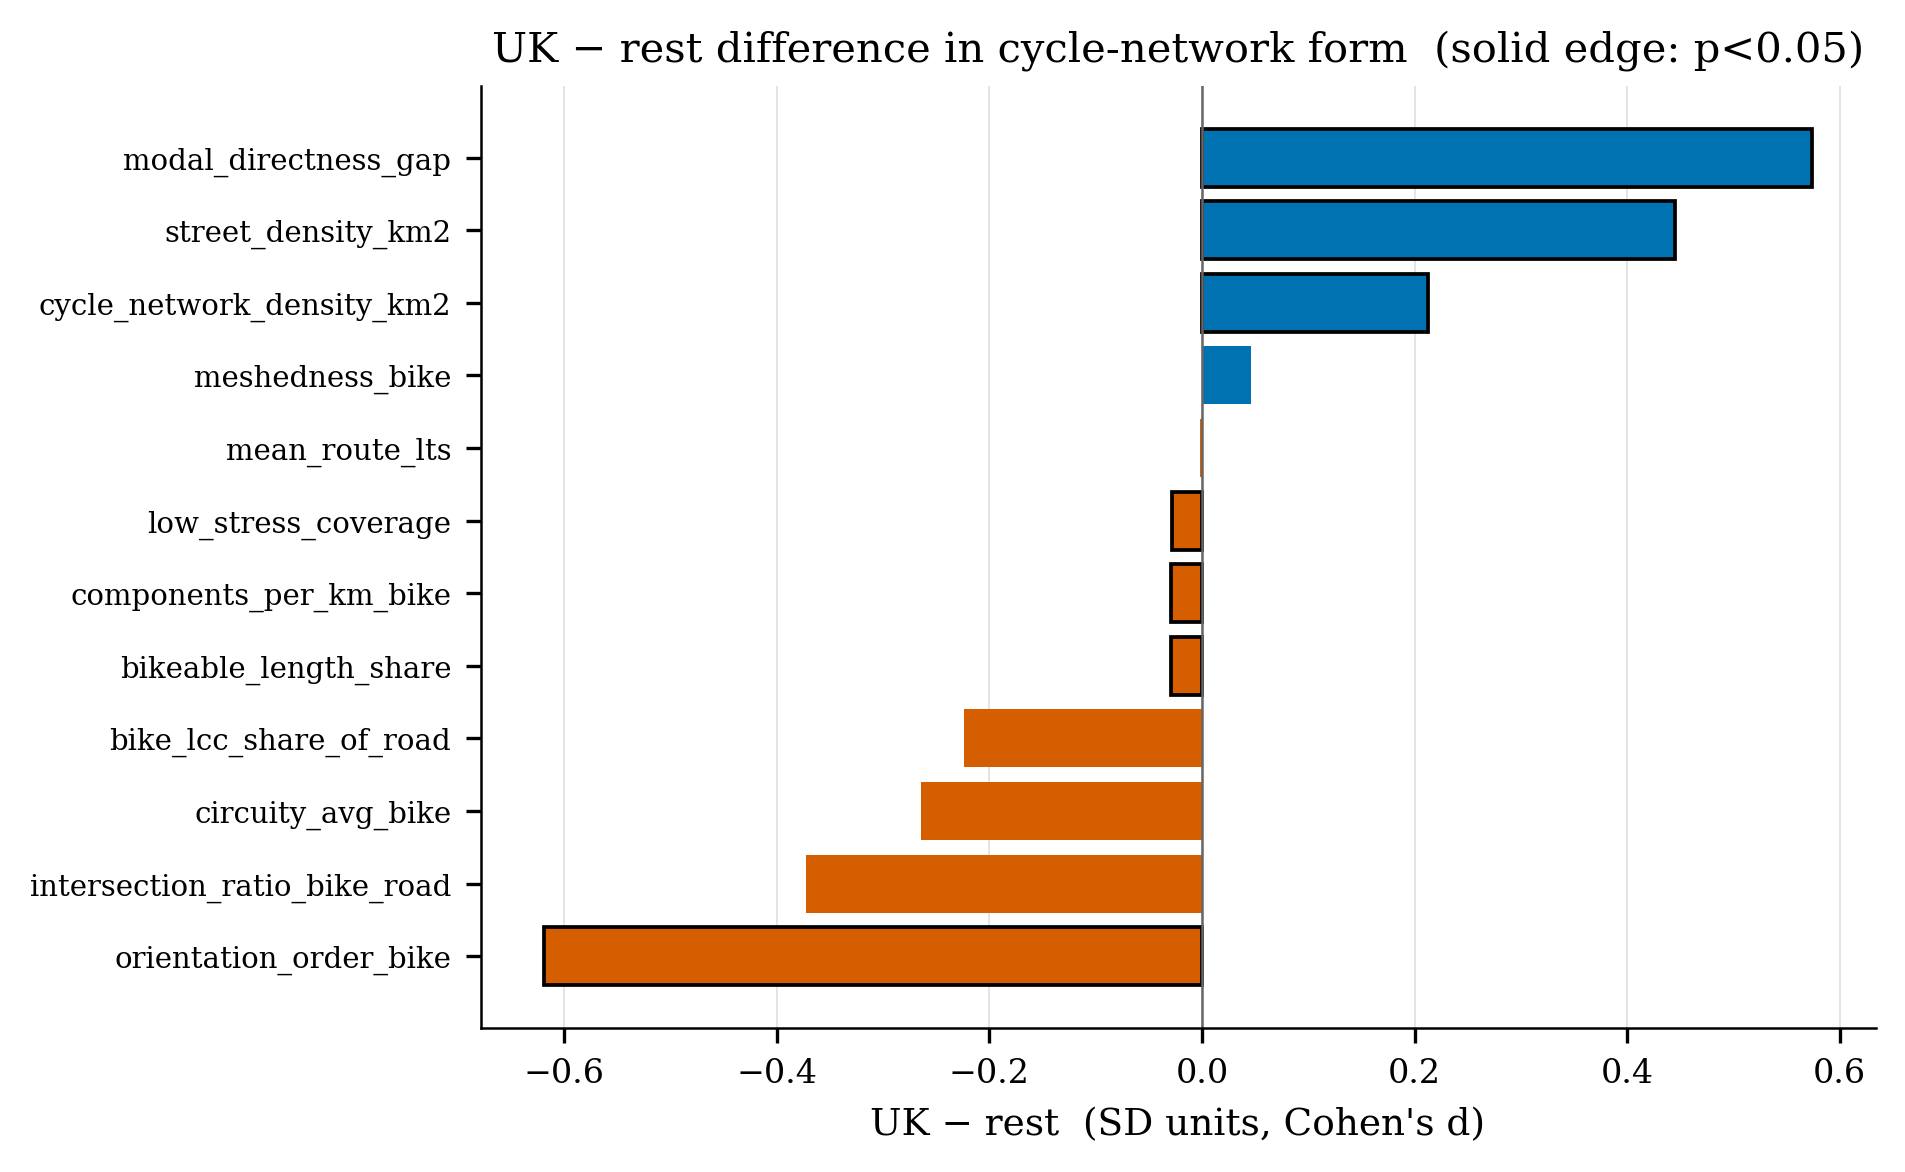

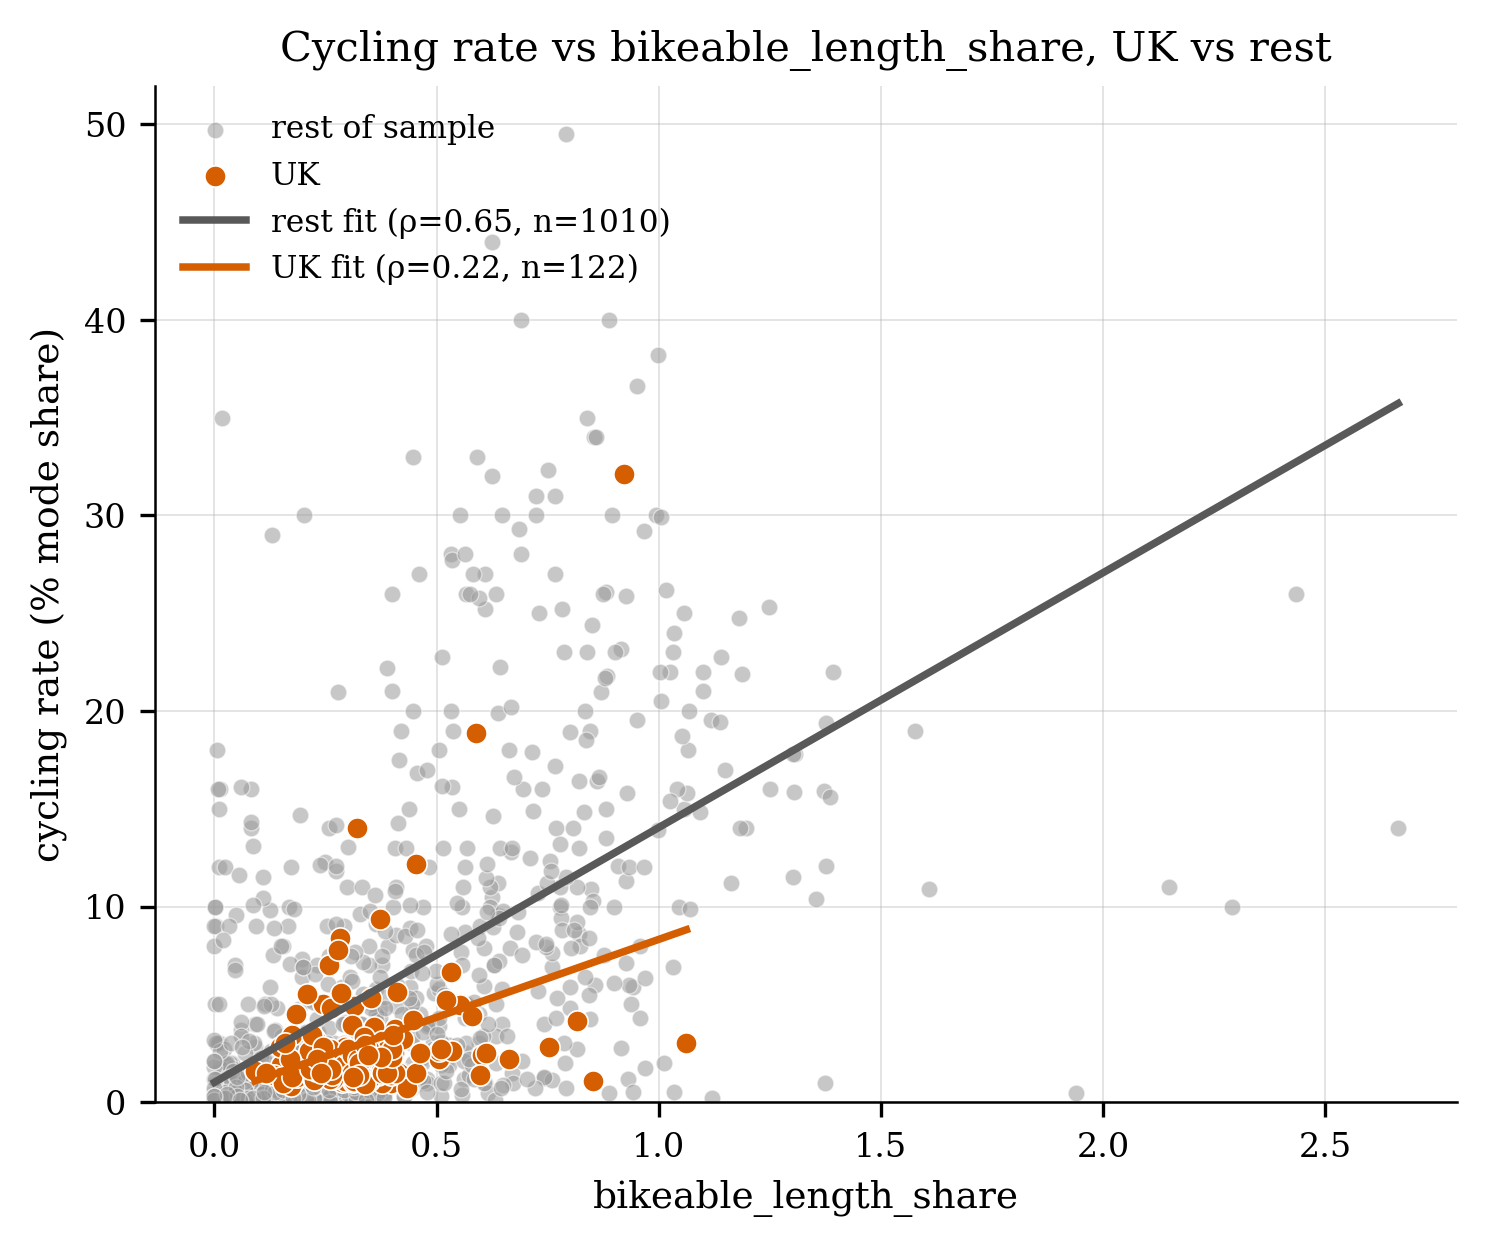

In [5]:
# Descriptive & UK-vs-rest paper figures (regenerated by make_figures above)
for _name in ['cycling_rate_distribution', 'cycling_rate_by_country',
              'uk_vs_rest_metrics', 'uk_vs_rest_relationship']:
    display(Image(str(FIGDIR / f'{_name}.png')))

## 4. Predictive model figures + tables

In [6]:
res = report.make_model_report()   # pred-vs-actual (±labels) + feature importance
display(res['performance'])
res['importance'].head(15)

,feature_set,model,cv_r2,cv_r2_sd,cv_rmse,n
0,form,elasticnet,0.483,0.034,5.468,1132
1,form,random_forest,0.606,0.036,4.768,1132
2,country,elasticnet,0.614,0.029,4.730,1132
3,country,random_forest,0.616,0.029,4.713,1132
4,form+country,elasticnet,0.641,0.012,4.561,1132
5,form+country,random_forest,0.670,0.015,4.368,1132


,metric,importance,importance_sd
0,bikeable_length_share,0.5959,0.0268
1,meshedness_bike,0.1002,0.0089
2,circuity_avg_bike,0.0976,0.0073
3,modal_directness_gap,0.0874,0.0082
4,intersection_ratio_bike_road,0.0818,0.0057
5,bike_offroad_share,0.0464,0.0046
6,street_density_km2,0.0223,0.0011
7,orientation_order_road,0.0172,0.0020
8,lts1_coverage,0.0171,0.0016
9,low_stress_coverage,0.0158,0.0010


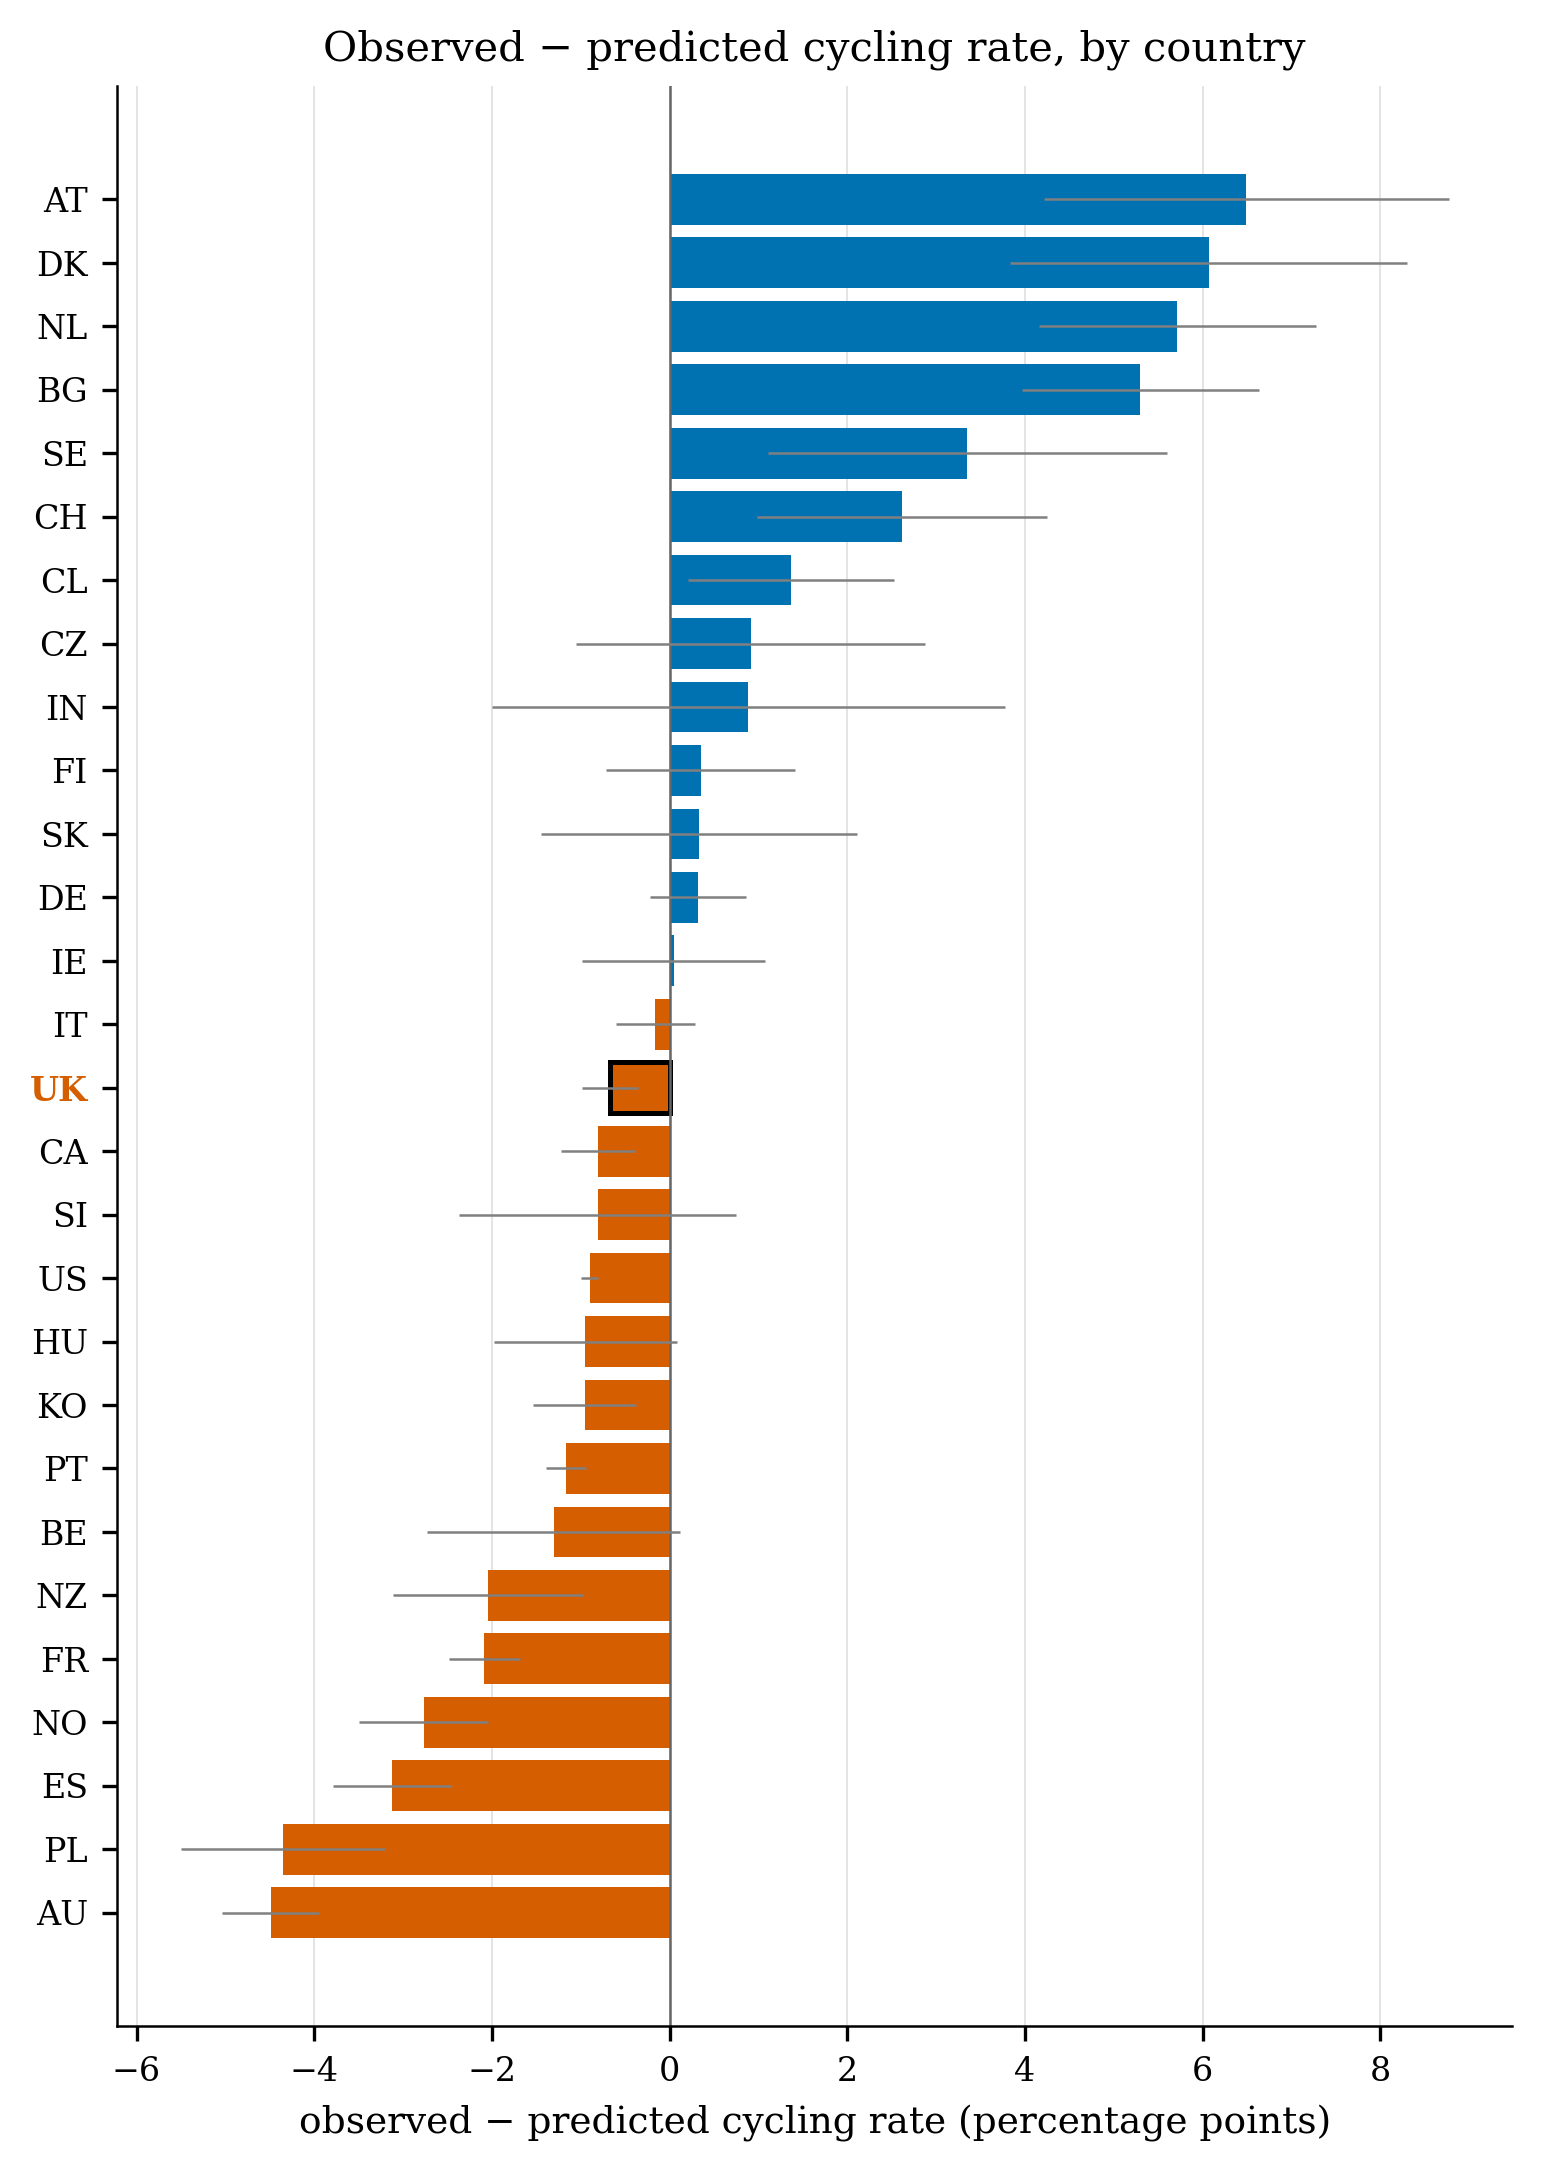

In [7]:
# Implementation gap: does a country cycle more/less than its network form predicts?
# (generated by make_model_report above; residual of the form-only out-of-fold model)
display(Image(str(FIGDIR / 'implementation_gap_by_country.png')))

## 5. Grown-network scenario (optional)

Only runs if you've already produced scenario results with `python run_scenarios.py`
(see `SCENARIOS.md`). Draws the metric-shift, predicted-rate-shift and form-space
movement figures for the Tyne & Wear boroughs. Two predicted-rate views are shown:
the **full-fit** estimate (model trained on the whole dataset) and the **out-of-fold**
estimate (each borough held out of training — the honest read of the predicted change).

scenario figures: ['scenario_shift_Gateshead__United_Kingdom.png', 'scenario_shift_Newcastle_upon_Tyne__United_Kingdom.png', 'scenario_shift_North_Tyneside__United_Kingdom.png', 'scenario_shift_South_Tyneside__United_Kingdom.png', 'scenario_shift_Sunderland__United_Kingdom.png', 'scenario_prediction_shift.png', 'scenario_oof_prediction_shift.png', 'scenario_pred_vs_actual_shift.png', 'scenario_typology_shift.png']

Full-fit prediction (borough included in training):


,place_id,baseline_pred,scenario_pred,shift,observed
0,"Gateshead, United Kingdom",1.868334,18.093916,16.225582,1.509054
1,"Newcastle upon Tyne, United Kingdom",2.495943,16.098359,13.602416,2.300000
2,"North Tyneside, United Kingdom",4.349818,18.544171,14.194352,2.628918
3,"South Tyneside, United Kingdom",3.024293,16.643148,13.618855,2.346939
4,"Sunderland, United Kingdom",1.637970,16.492355,14.854385,1.412714


Out-of-fold prediction (each borough held out — the honest estimate):


,place_id,baseline_oof,scenario_oof,shift,observed
0,"Gateshead, United Kingdom",2.740100,18.037690,15.297590,1.509054
1,"Newcastle upon Tyne, United Kingdom",3.132285,15.931462,12.799178,2.300000
2,"North Tyneside, United Kingdom",5.553384,18.267660,12.714276,2.628918
3,"South Tyneside, United Kingdom",4.678859,16.585096,11.906237,2.346939
4,"Sunderland, United Kingdom",2.186492,16.916427,14.729935,1.412714


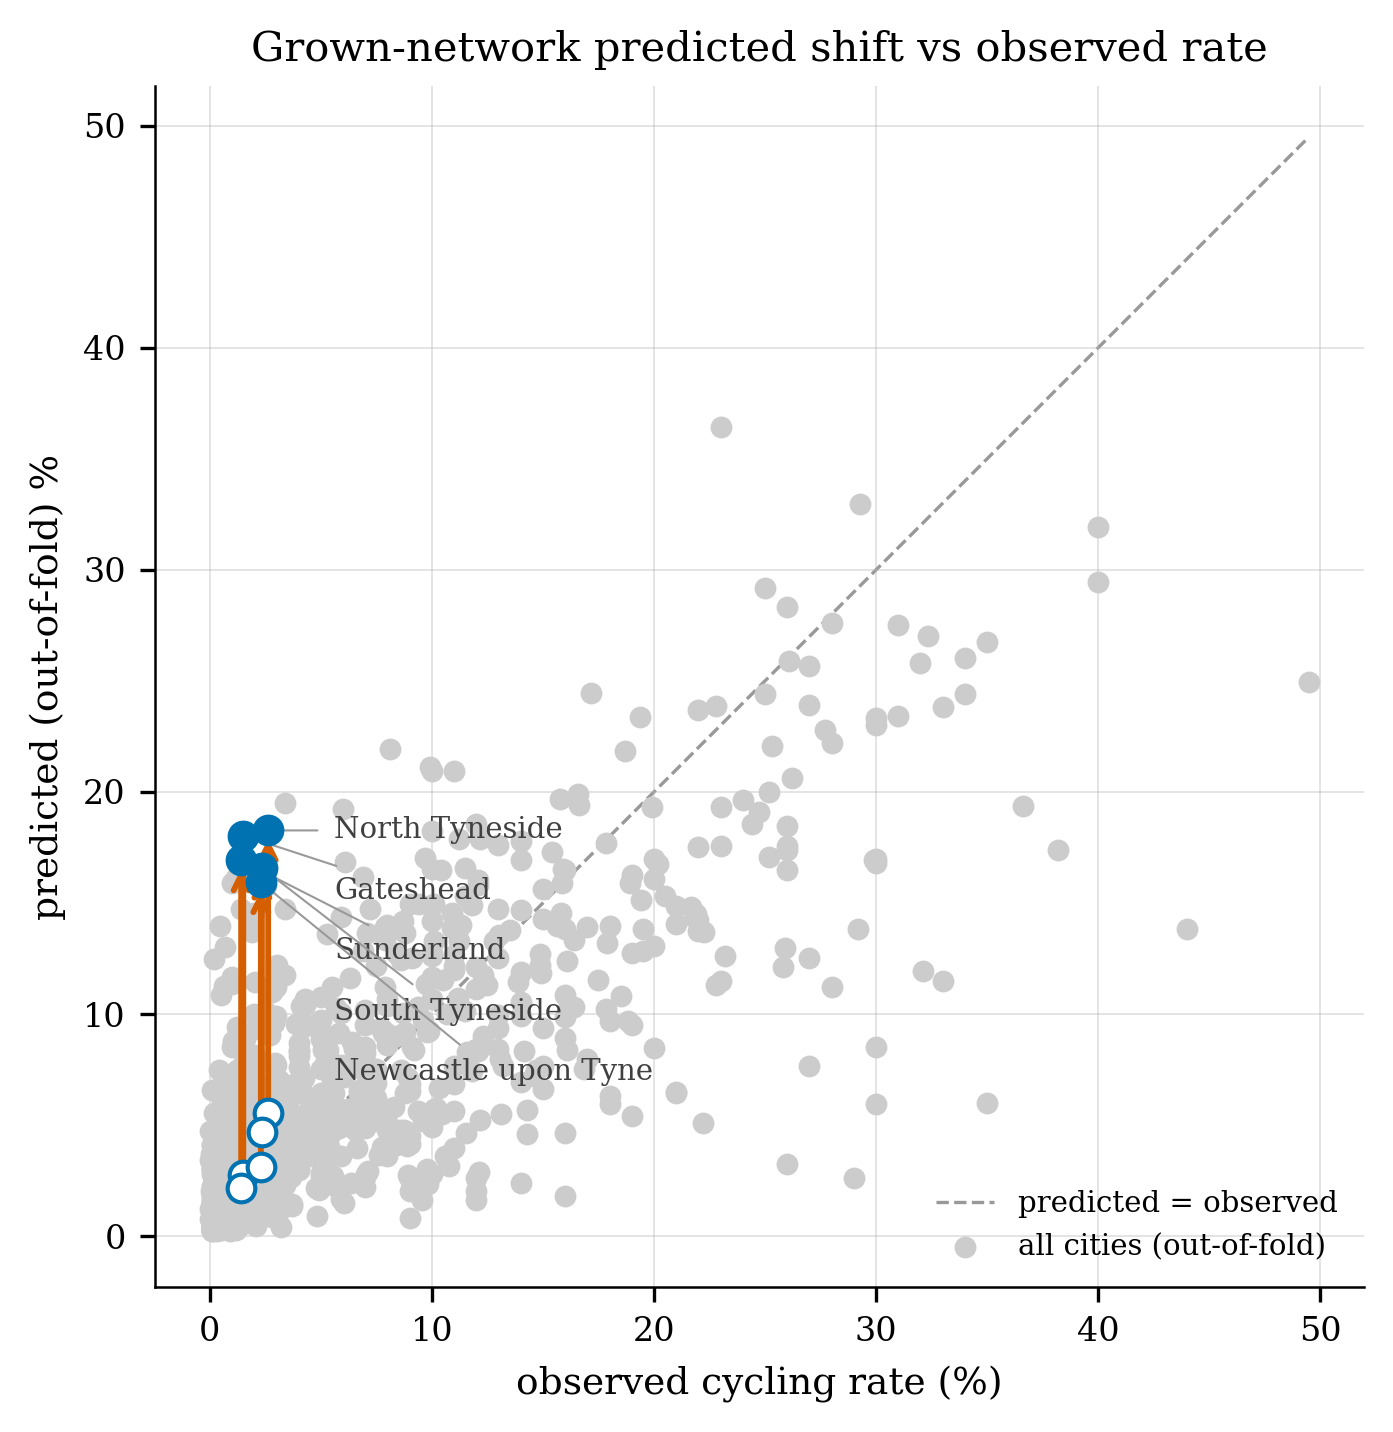

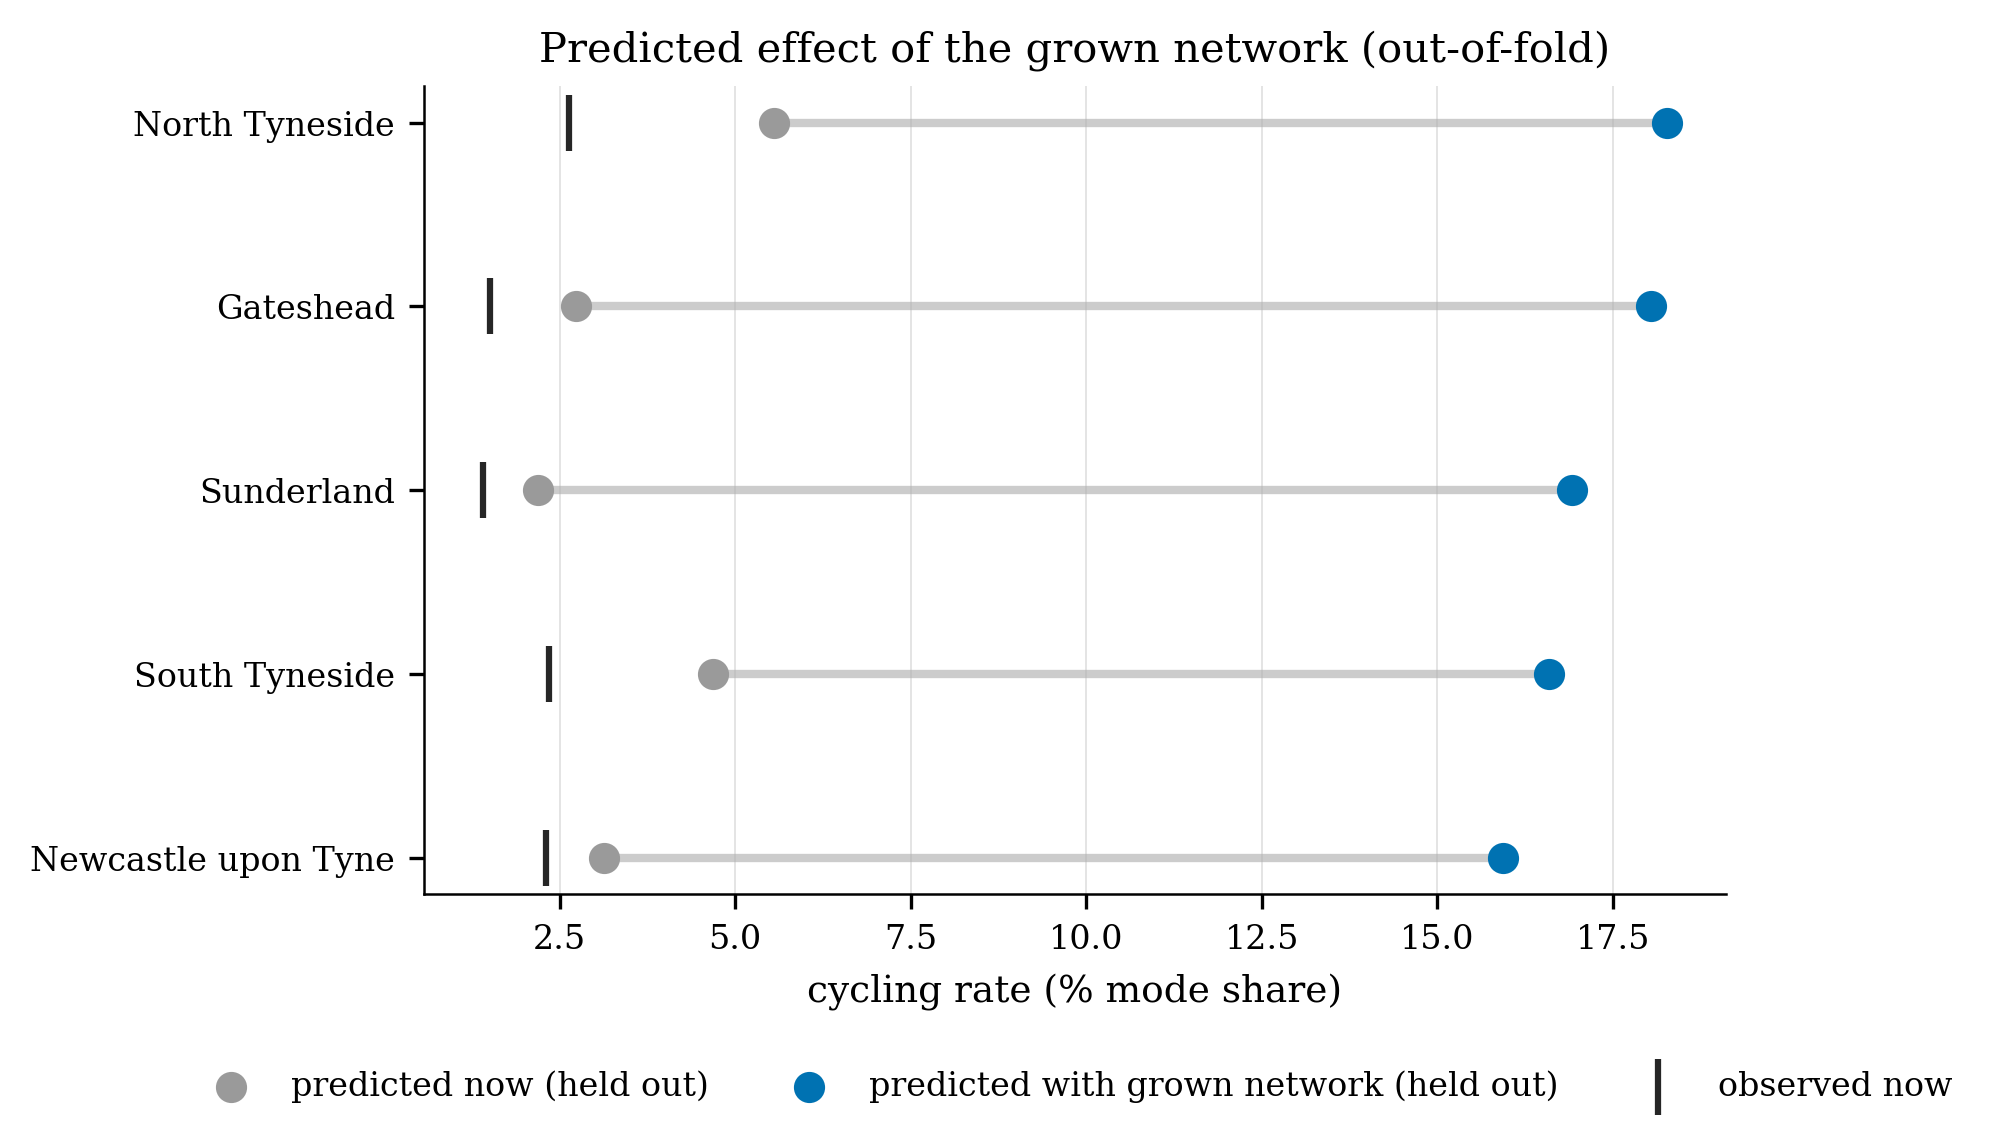

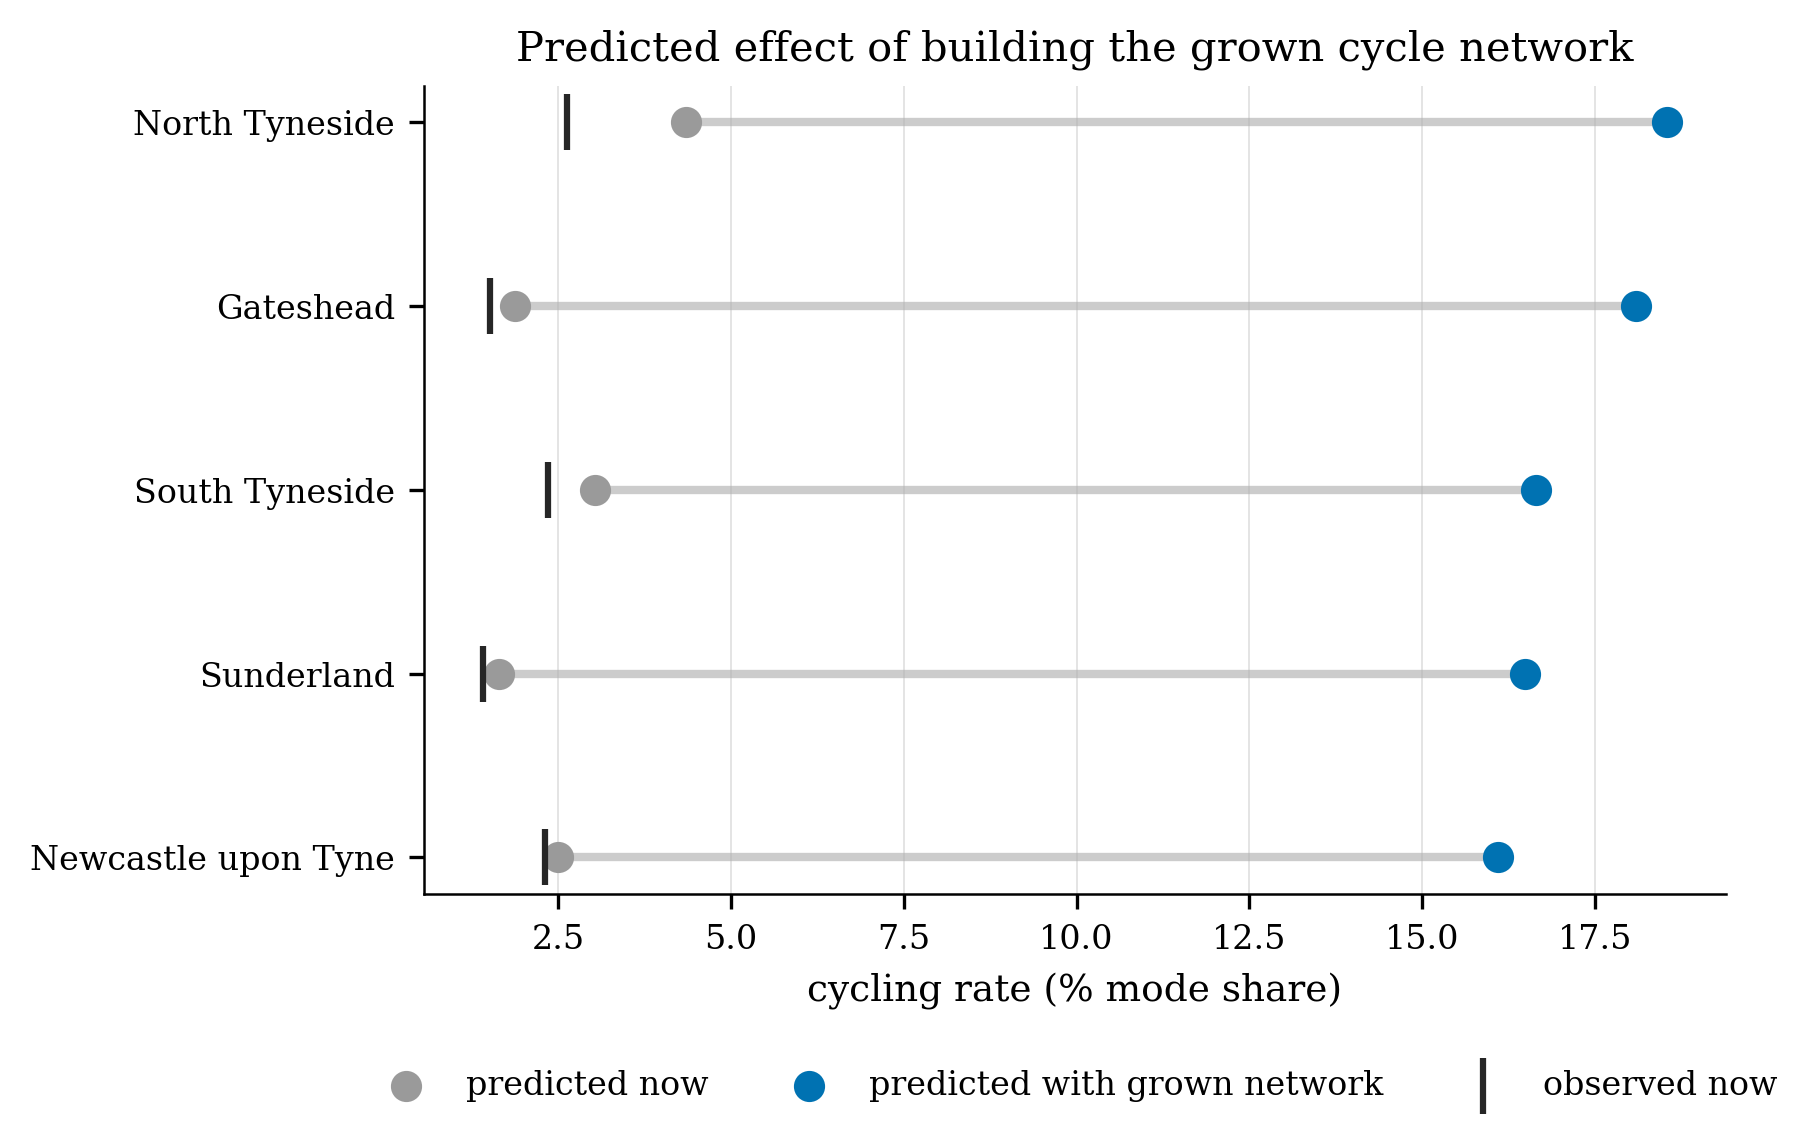

In [8]:
if not scenarios.build_scenario_table().empty:
    sres = report.make_scenario_report()
    print('scenario figures:', [p.name for p in sres['figures']])
    print('\nFull-fit prediction (borough included in training):')
    display(sres['predictions'])
    print('Out-of-fold prediction (each borough held out — the honest estimate):')
    display(sres['predictions_oof'])
    for name in ('scenario_pred_vs_actual_shift.png', 'scenario_oof_prediction_shift.png',
                 'scenario_prediction_shift.png'):
        display(Image(str(FIGDIR / name)))
else:
    print('No scenario results yet — run `python run_scenarios.py` first (see SCENARIOS.md).')

## 6. Preview a few (everything is on disk in `results/figures/`)

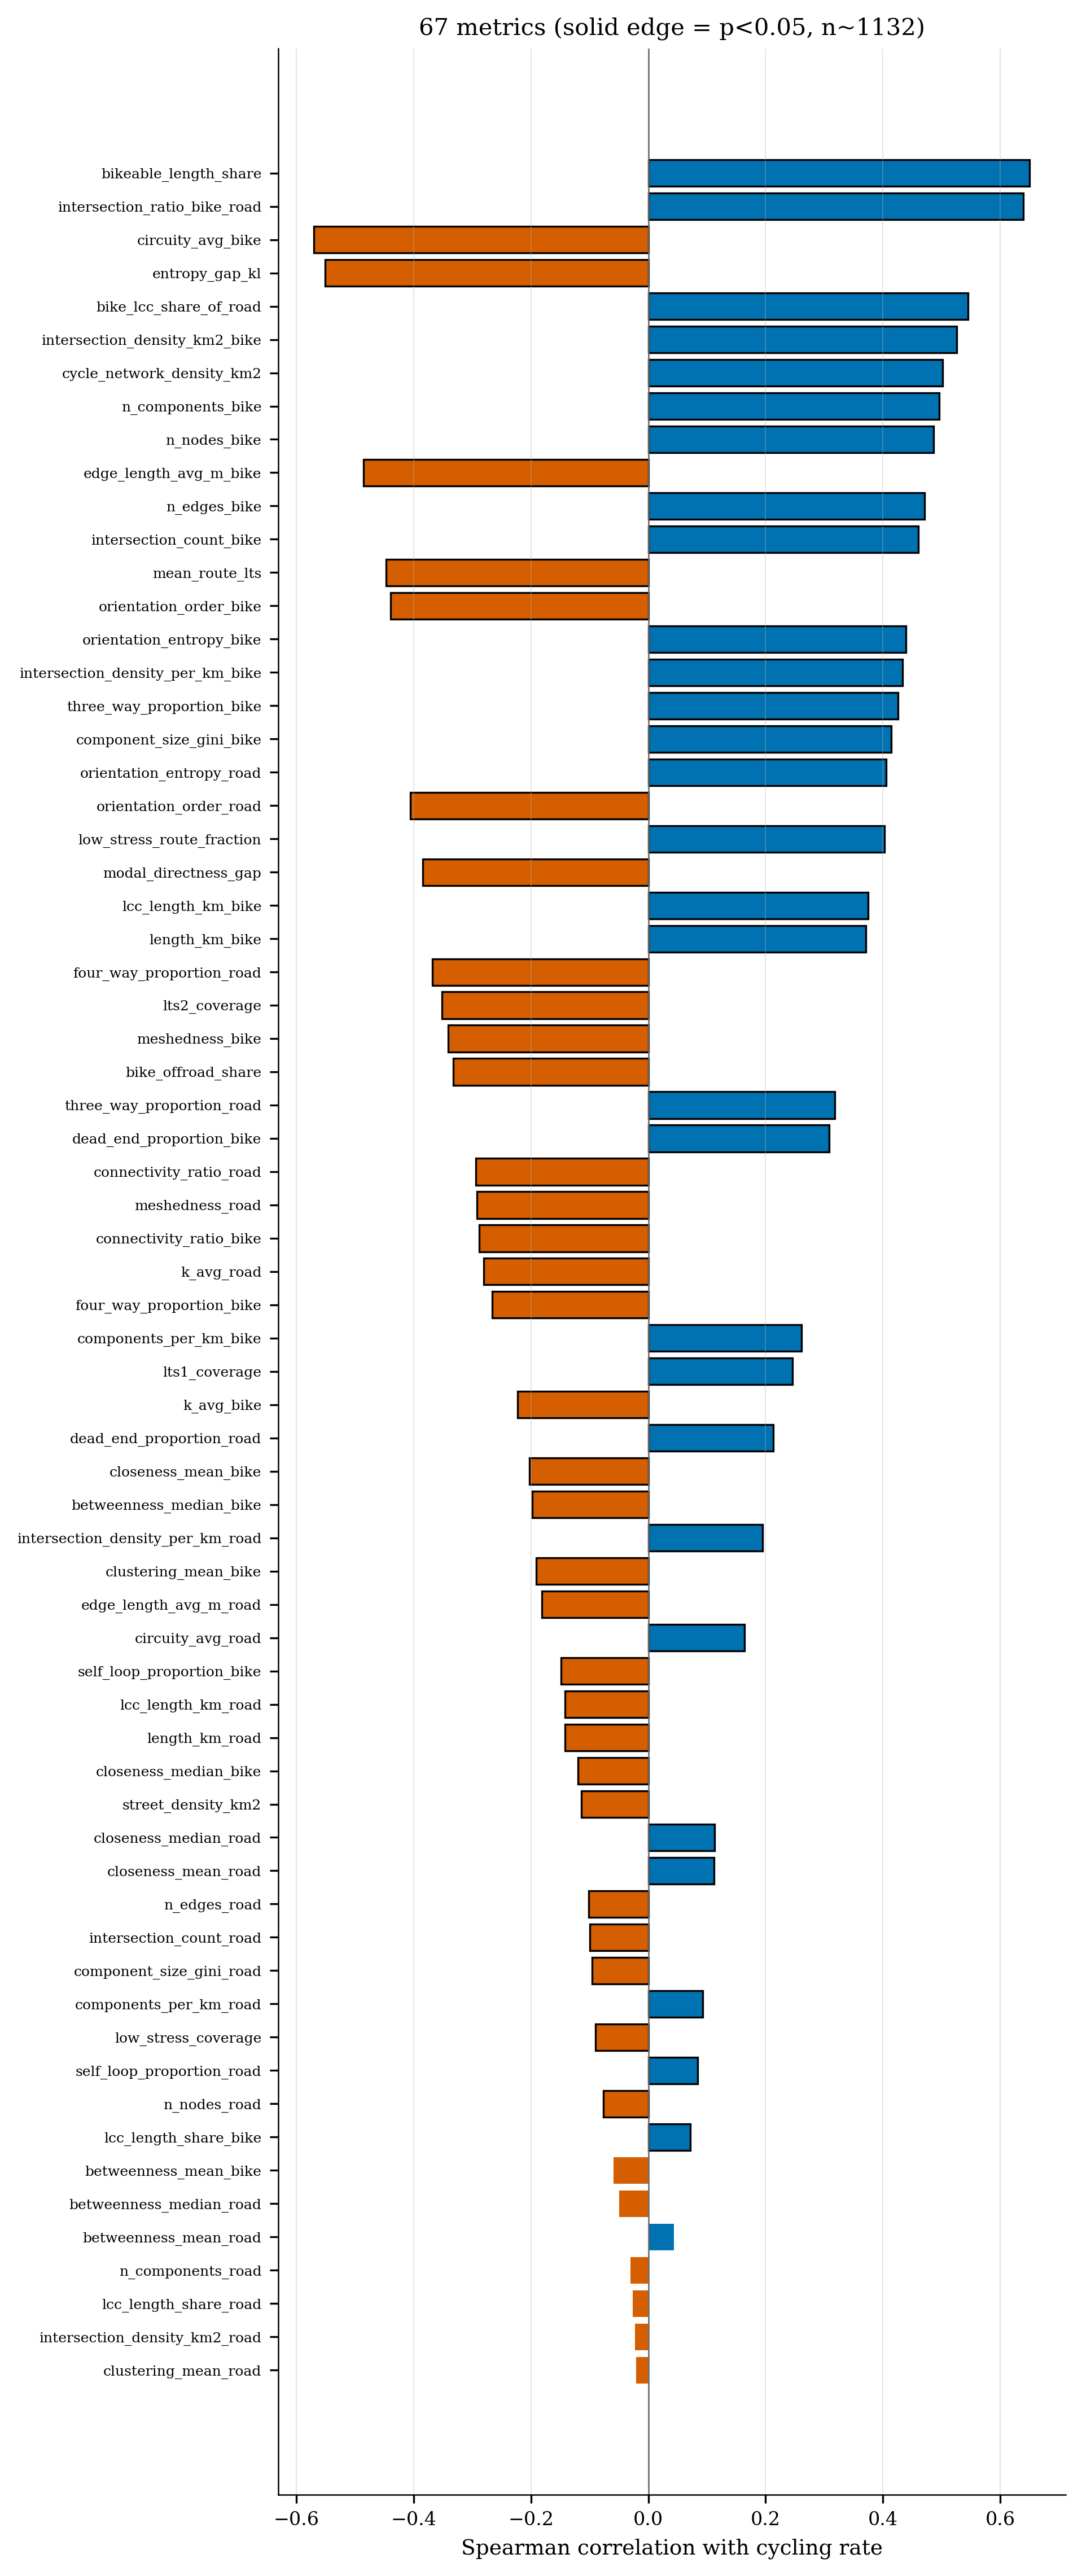

In [9]:
Image(str(FIGDIR / 'correlations_vs_cycling.png'))

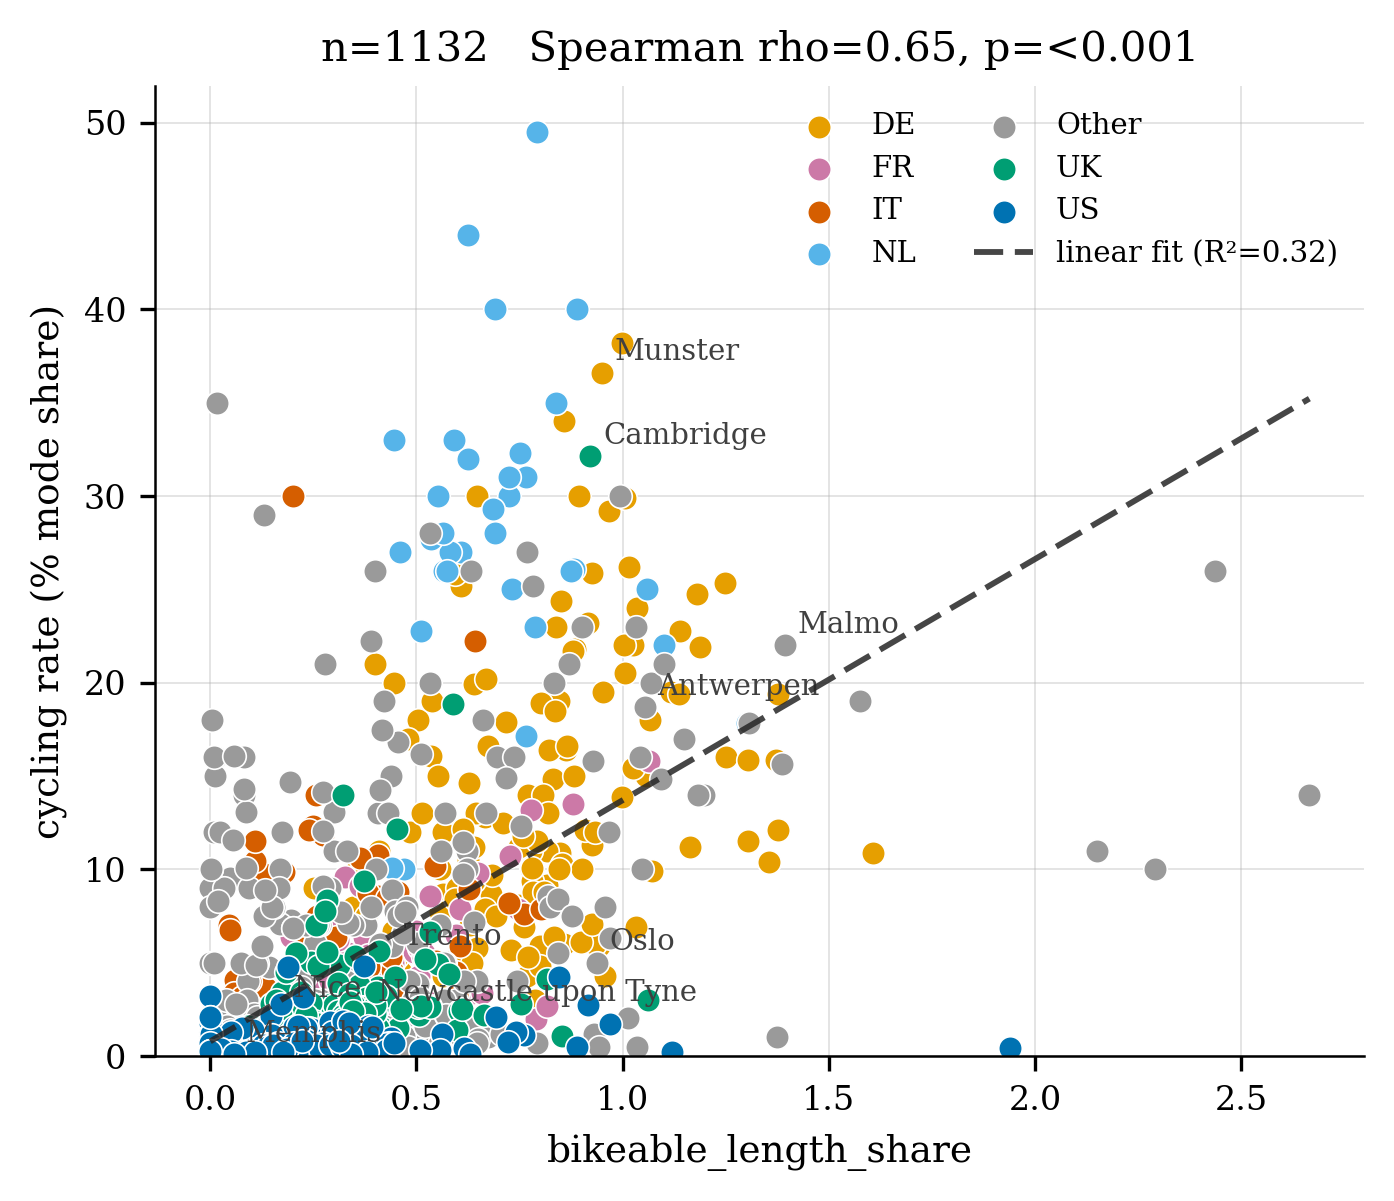

In [10]:
Image(str(FIGDIR / 'outcome_vs_bikeable_length_share_labeled.png'))

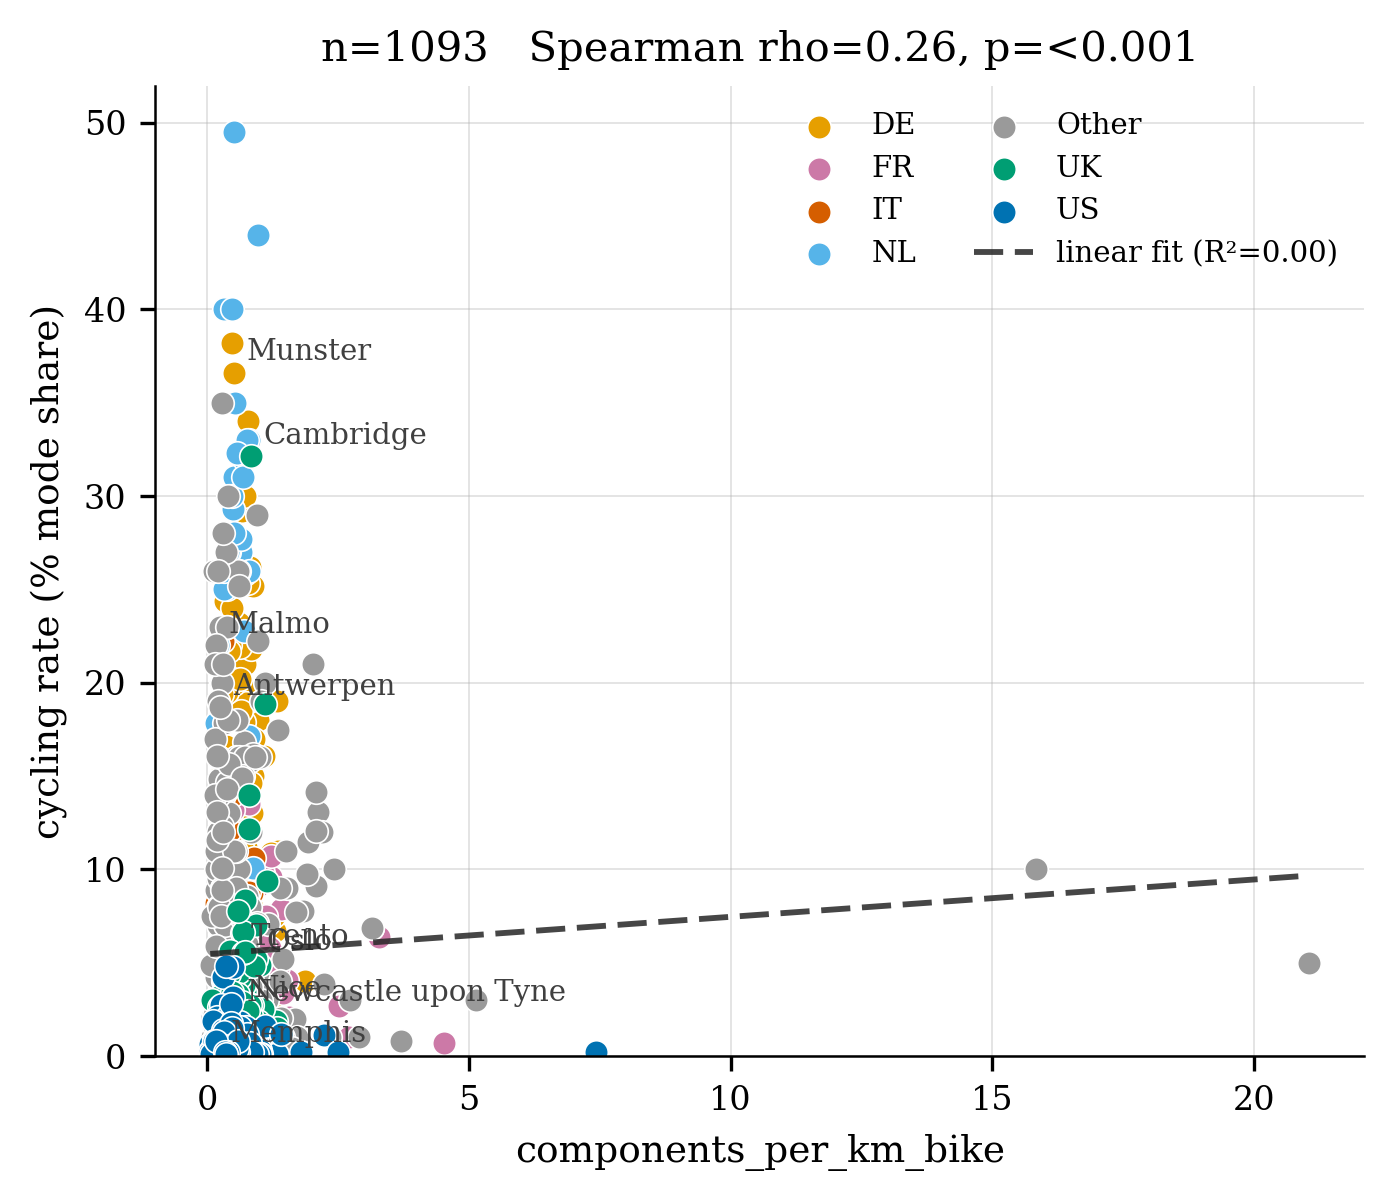

In [11]:
Image(str(FIGDIR / 'outcome_vs_components_per_km_bike_labeled.png'))

In [12]:
# full inventory
figs = sorted(p.name for p in FIGDIR.glob('*.png'))
print(len(figs), 'PNGs |', sum(n.endswith('_labeled.png') for n in figs), 'labelled |',
      len(list(FIGDIR.glob('*.pdf'))), 'PDFs')
figs[:40]

175 PNGs | 73 labelled | 0 PDFs


['bike_vs_road_circuity_avg.png',
 'bike_vs_road_circuity_avg_labeled.png',
 'bike_vs_road_lcc_length_share.png',
 'bike_vs_road_lcc_length_share_labeled.png',
 'bike_vs_road_meshedness.png',
 'bike_vs_road_meshedness_labeled.png',
 'bike_vs_road_orientation_entropy.png',
 'bike_vs_road_orientation_entropy_labeled.png',
 'correlations_vs_cycling.png',
 'cycling_rate_by_country.png',
 'cycling_rate_distribution.png',
 'group_centrality.png',
 'group_connectivity_edge.png',
 'group_connectivity_node.png',
 'group_fragmentation.png',
 'group_lts_coverage.png',
 'group_relational.png',
 'group_shape_orientation.png',
 'group_size.png',
 'implementation_gap_by_country.png',
 'metric_correlation_heatmap.png',
 'model_feature_importance.png',
 'model_pred_vs_actual.png',
 'model_pred_vs_actual_labeled.png',
 'outcome_vs_betweenness_mean_bike.png',
 'outcome_vs_betweenness_mean_bike_labeled.png',
 'outcome_vs_betweenness_mean_road.png',
 'outcome_vs_betweenness_mean_road_labeled.png',
 'outcom

## 7. Plain-text results digest 

Writes `results/report.md` — a self-describing markdown summary of the dataset, correlations, model, contrasts, typology and caveats. Reads saved tables only (fast); regenerate any time. 

In [13]:
p = report.text_report()
print('wrote', p)
print(p.read_text(encoding='utf-8')[:2000])

wrote C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\bikeNetworksEDA\2026_edition\results\report.md
# cycleform — results summary

_Generated 2026-07-27 · metric_version 0.5.0 · snapshot 2025-01-01_

**Study question.** Is the *form/structure* of a city's cycle network (and the road network it sits in) associated with its cycling rate across many cities, and can cycling rate be predicted from network form? Metrics are computed identically on real OSM cities and on Chapter-5 grown networks. This is a descriptive + predictive screen, not causal inference.

## 1. Dataset

- **1137 input places** with network metrics computed.
- **1132** of them have an observed cycling rate (the modelled sample).
- UK places: **123**.
- Top countries by place count: {'US': 338, 'DE': 150, 'UK': 123, 'IT': 91, 'FR': 85, 'NL': 34, 'ES': 26, 'CA': 25}.

Cycling-rate outcome by source (one preferred source per place, ModalShare first, then OECD FUA, then legacy):

| source | places used | 